<a href="https://colab.research.google.com/github/gracey25/us-foreign-aid-democracy-analysis/blob/main/notebooks/02_eda_visualizations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from scipy.stats import pearsonr

# Create nested directory structure automatically
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../outputs", exist_ok=True)

# Upload CSV from your computer

# Set global style
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

In [3]:
# ==========================================
# 1. LOAD PROCESSED PANEL DATASET
# ==========================================
df = pd.read_csv("../data/processed/merged_vdem_aid_panel.csv")

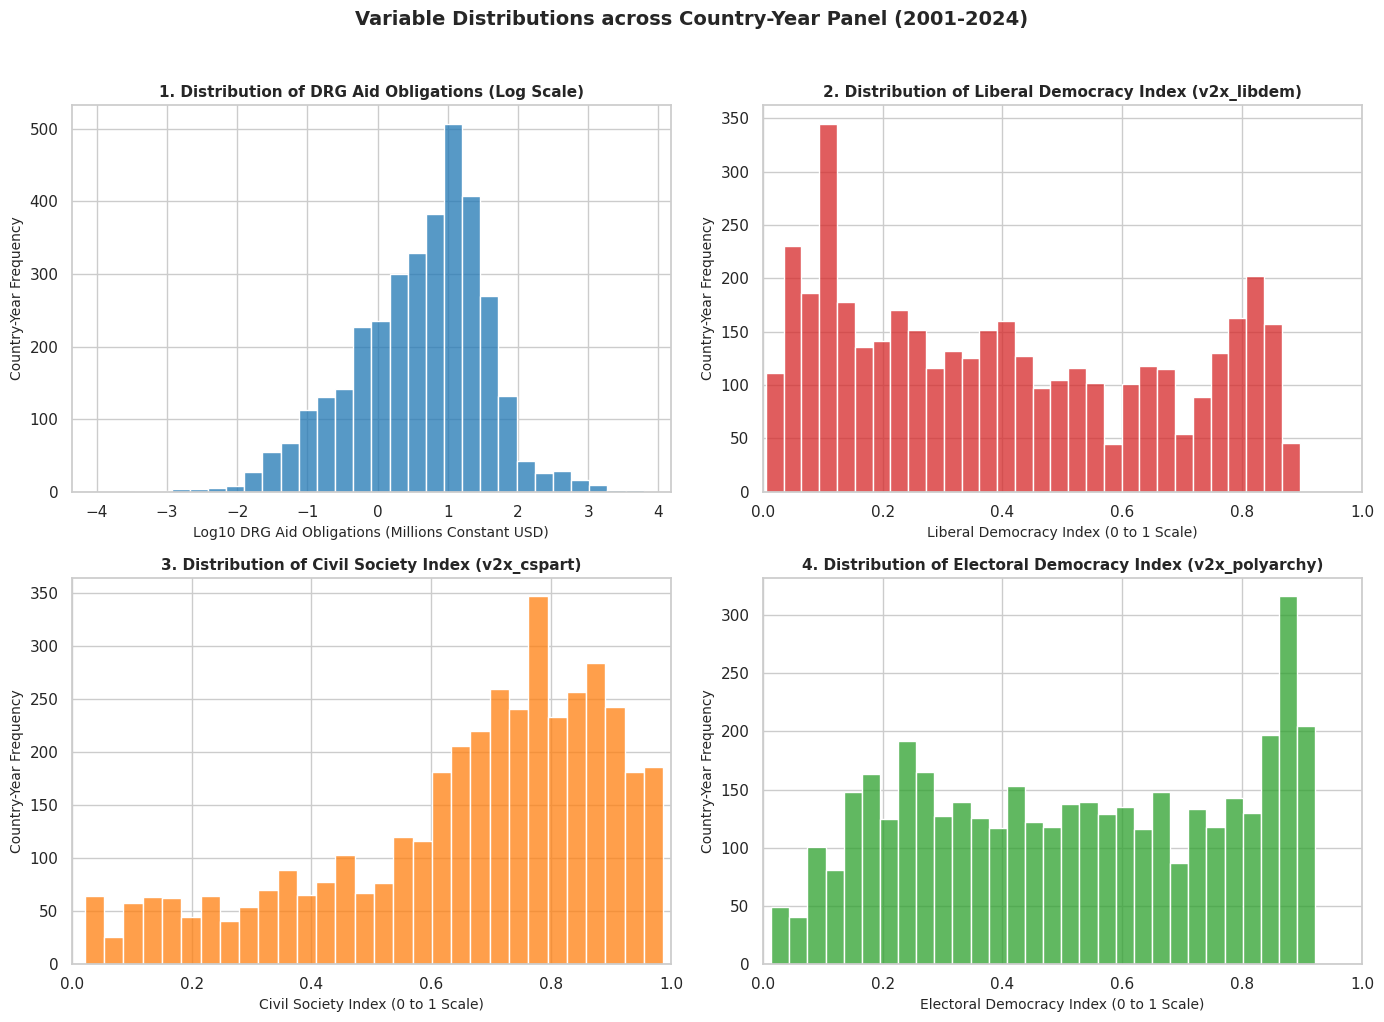

Histogram grid saved successfully to: ../outputs/fig_variable_distributions_2x2.png


In [18]:
# ==========================================
# SINGLE VARIABLE VISUALIZATIONS
# ==========================================

# Create 2x2 grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# Color palette for variables
colors = {
    'aid': '#1f77b4',       # Slate Blue
    'libdem': '#d62728',    # Crimson Red
    'cspart': '#ff7f0e',    # Amber Orange
    'polyarchy': '#2ca02c'  # Emerald Green
}

# ---------------------------------------------------------
# 1. Distribution of DRG Aid Obligations (Log Scale)
# ---------------------------------------------------------
df['aid_millions'] = df['aid_constant_amount'] / 1e6
aid_data = df[df['aid_millions'] > 0]['aid_millions']
log_aid_data = np.log10(aid_data) # used log bc there are some enormous outliers on the upper end

sns.histplot(
    log_aid_data,
    kde=False,
    color=colors['aid'],
    ax=axes[0, 0],
    bins=30
)
axes[0, 0].set_title('1. Distribution of DRG Aid Obligations (Log Scale)', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Log10 DRG Aid Obligations (Millions Constant USD)', fontsize=10)
axes[0, 0].set_ylabel('Country-Year Frequency', fontsize=10)

# ---------------------------------------------------------
# 2. Distribution of Liberal Democracy Index (v2x_libdem)
# ---------------------------------------------------------
sns.histplot(
    df['v2x_libdem'].dropna(),
    kde=False,
    color=colors['libdem'],
    ax=axes[0, 1],
    bins=30
)
axes[0, 1].set_title('2. Distribution of Liberal Democracy Index (v2x_libdem)', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Liberal Democracy Index (0 to 1 Scale)', fontsize=10)
axes[0, 1].set_ylabel('Country-Year Frequency', fontsize=10)
axes[0, 1].set_xlim(0, 1)

# ---------------------------------------------------------
# 3. Distribution of Civil Society Participation Index (v2x_cspart)
# ---------------------------------------------------------
sns.histplot(
    df['v2x_cspart'].dropna(),
    kde=False,
    color=colors['cspart'],
    ax=axes[1, 0],
    bins=30
)
axes[1, 0].set_title('3. Distribution of Civil Society Index (v2x_cspart)', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Civil Society Index (0 to 1 Scale)', fontsize=10)
axes[1, 0].set_ylabel('Country-Year Frequency', fontsize=10)
axes[1, 0].set_xlim(0, 1)

# ---------------------------------------------------------
# 4. Distribution of Electoral Democracy Index (v2x_polyarchy)
# ---------------------------------------------------------
sns.histplot(
    df['v2x_polyarchy'].dropna(),
    kde=False,
    color=colors['polyarchy'],
    ax=axes[1, 1],
    bins=30
)
axes[1, 1].set_title('4. Distribution of Electoral Democracy Index (v2x_polyarchy)', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Electoral Democracy Index (0 to 1 Scale)', fontsize=10)
axes[1, 1].set_ylabel('Country-Year Frequency', fontsize=10)
axes[1, 1].set_xlim(0, 1)

plt.suptitle('Variable Distributions across Country-Year Panel (2001-2024)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Save FIRST, then display
output_dist_path = "../outputs/fig_variable_distributions_2x2.png"
plt.savefig(output_dist_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Histogram grid saved successfully to: {output_dist_path}")

Q1 (25th Pct): $1.02M
Q3 (75th Pct): $17.20M
IQR: $16.19M
Upper Threshold (Q3 + 1.5*IQR): $41.48M
Excluded 340 outlier observations above $41.48M


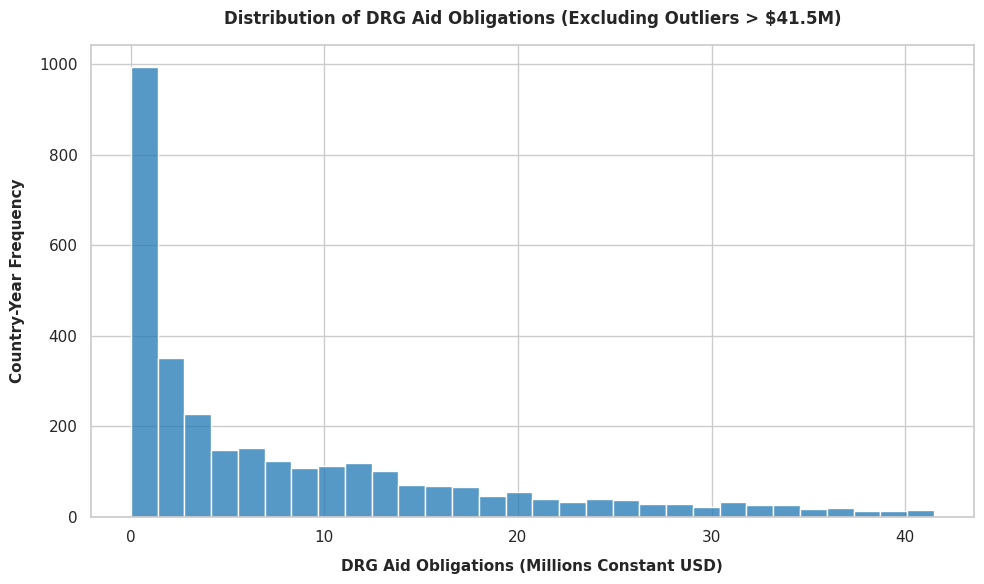

Filtered histogram saved to: ../outputs/fig_aid_histogram_no_outliers.png


In [19]:
# ==========================================
# VISUALIZATION OF RAW AID DATA (NOT LOG) WITH OUTLIERS EXCLUDED
# ==========================================

# Select aid data (filtering to positive allocations)
aid_series = df[df['aid_millions'] > 0]['aid_millions']

# Compute quartiles and IQR
q1 = aid_series.quantile(0.25)
q3 = aid_series.quantile(0.75)
iqr = q3 - q1

# Define upper bound (1.5 IQRs above Q3)
upper_bound = q3 + (1.5 * iqr)

# Filter aid data within 1.5 IQRs of the upper bound
filtered_aid = aid_series[aid_series <= upper_bound]

# Report observations removed
removed_count = len(aid_series) - len(filtered_aid)
print(f"Q1 (25th Pct): ${q1:.2f}M")
print(f"Q3 (75th Pct): ${q3:.2f}M")
print(f"IQR: ${iqr:.2f}M")
print(f"Upper Threshold (Q3 + 1.5*IQR): ${upper_bound:.2f}M")
print(f"Excluded {removed_count} outlier observations above ${upper_bound:.2f}M")

# Plot raw histogram without log scale
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    filtered_aid,
    bins=30,
    kde=False,
    color='#1f77b4',
    ax=ax
)

ax.set_title(f'Distribution of DRG Aid Obligations (Excluding Outliers > ${upper_bound:.1f}M)', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('DRG Aid Obligations (Millions Constant USD)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Country-Year Frequency', fontsize=11, fontweight='bold', labelpad=10)

plt.tight_layout()

# Save FIRST, then display
output_filtered_path = "../outputs/fig_aid_histogram_no_outliers.png"
plt.savefig(output_filtered_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Filtered histogram saved to: {output_filtered_path}")

In [14]:
# Count observations above 300
count_above_300 = (aid_data > 1000).sum()

# Calculate total valid observations and percentage
total_obs = len(aid_data)
pct_above_300 = (count_above_300 / total_obs) * 100

print(f"Number of aid observations > 300: {count_above_300}")
print(f"Total non-null aid observations: {total_obs}")
print(f"Percentage of sample above 300: {pct_above_300:.2f}%")

Number of aid observations > 300: 14
Total non-null aid observations: 4881
Percentage of sample above 300: 0.29%


In [9]:
# ==========================================
# NUMERIC SUMMARIES
# ==========================================

# List of target variables
target_vars = [
    'aid_millions',
    'v2x_libdem',
    'v2x_cspart',
    'v2x_polyarchy'
]

# Generate descriptive statistics dataframe
summary_stats = df[target_vars].describe().T

# Add missing values count and rename columns for clean presentation
summary_stats = summary_stats.rename(columns={
    'count': 'N',
    'mean': 'Mean',
    'std': 'Std Dev',
    'min': 'Min',
    '25%': '25th Pct',
    '50%': 'Median',
    '75%': '75th Pct',
    'max': 'Max'
})

# Reorder columns logically
cols_order = ['N', 'Mean', 'Std Dev', 'Min', '25th Pct', 'Median', '75th Pct', 'Max']
summary_stats = summary_stats[cols_order]

# Display formatted summary table
print("=== DESCRIPTIVE STATISTICS: NUMERIC VARIABLES ===")
display(summary_stats.round(2))

# Save summary statistics to CSV for Phase 3 reporting
output_csv_path = "../outputs/table1_descriptive_statistics.csv"
summary_stats.to_csv(output_csv_path)

print(f"\n✅ Summary statistics successfully saved to: {output_csv_path}")

=== DESCRIPTIVE STATISTICS: NUMERIC VARIABLES ===


,N,Mean,Std Dev,Min,25th Pct,Median,75th Pct,Max
aid_millions,4881.0,21.20,146.99,-60.37,0.00,1.52,11.53,6173.09
v2x_libdem,4101.0,0.40,0.27,0.00,0.15,0.37,0.64,0.90
v2x_cspart,4101.0,0.66,0.24,0.02,0.54,0.72,0.84,0.99
v2x_polyarchy,4101.0,0.51,0.26,0.01,0.28,0.52,0.76,0.92



✅ Summary statistics successfully saved to: ../outputs/table1_descriptive_statistics.csv


In [ ]:
# ==========================================
# 2. GENERATE GLOBAL SUMMARY TABLE
# ==========================================
# Aggregate global DRG aid totals and mean democracy indices by year
global_summary = df.groupby('year').agg(
    total_drg_aid=('aid_constant_amount', 'sum'),
    mean_polyarchy=('v2x_polyarchy', 'mean'),
    mean_libdem=('v2x_libdem', 'mean'),
    mean_cspart=('v2x_cspart', 'mean'),
    country_count=('country_text_id', 'nunique')
).reset_index()

# Format aid into millions of constant USD for readability
global_summary['total_drg_aid_millions'] = global_summary['total_drg_aid'] / 1e6

print("--- GLOBAL MACRO TREND SUMMARY (2001–2024) ---")
display(global_summary.head(10))

--- GLOBAL MACRO TREND SUMMARY (2001–2024) ---


,year,total_drg_aid,mean_polyarchy,mean_libdem,mean_cspart,country_count,total_drg_aid_millions
0,2001,3.211344e+09,0.493226,0.385266,0.638469,197,3211.344316
1,2002,2.125996e+09,0.504746,0.394107,0.642107,200,2125.996190
2,2003,8.529786e+09,0.511853,0.398147,0.647610,198,8529.785822
3,2004,6.644397e+09,0.512299,0.400011,0.652503,205,6644.397401
4,2005,7.059106e+09,0.516282,0.402565,0.656401,204,7059.106135
5,2006,3.414970e+09,0.519672,0.405226,0.657175,203,3414.970494
6,2007,4.030644e+09,0.516140,0.403433,0.657478,207,4030.644300
7,2008,4.582907e+09,0.519798,0.405680,0.661230,207,4582.907204
8,2009,5.676929e+09,0.521994,0.407213,0.662343,206,5676.928780
9,2010,6.465649e+09,0.523281,0.409062,0.670539,204,6465.649342


In [ ]:
# DELETE

df.head()

,country_name,country_text_id,year,aid_constant_amount,aid_delta,v2x_polyarchy,v2x_polyarchy_lag1,v2x_polyarchy_lag2,v2x_libdem,v2x_libdem_lag1,v2x_libdem_lag2,v2x_cspart,v2x_cspart_lag1,v2x_cspart_lag2
0,Afghanistan,AFG,2001,134538.0,NaN,0.083,0.073,0.073,0.028,0.022,0.022,0.127,0.045,0.045
1,Afghanistan,AFG,2002,105847567.0,105713029.0,0.218,0.083,0.073,0.085,0.028,0.022,0.615,0.127,0.045
2,Afghanistan,AFG,2003,48604770.0,-57242797.0,0.224,0.218,0.083,0.085,0.085,0.028,0.637,0.615,0.127
3,Afghanistan,AFG,2004,517702753.0,469097983.0,0.235,0.224,0.218,0.089,0.085,0.085,0.638,0.637,0.615
4,Afghanistan,AFG,2005,123433995.0,-394268758.0,0.311,0.235,0.224,0.111,0.089,0.085,0.665,0.638,0.637


In [ ]:
# ==========================================
# 3. PLOT DUAL-AXIS GLOBAL MACRO TRENDS
# ==========================================
# Match exact column names created in global_summary
indices = [
    ('mean_libdem', 'Mean Liberal Democracy Index', '#d62728'),      # Crimson Red
    ('mean_polyarchy', 'Mean Electoral Democracy Index', '#2ca02c'),  # Emerald Green
    ('mean_cspart', 'Mean Civil Society Index', '#ff7f0e')          # Amber Orange
]

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 12), sharex=True)
color_aid = '#1f77b4'

for ax1, (col, title, color_vdem) in zip(axes, indices):
    # Primary Axis: Total DRG Aid Obligations (Bars)
    ax1.bar(
        global_summary['year'],
        global_summary['total_drg_aid_millions'],
        color=color_aid,
        alpha=0.3,
        width=0.6,
        label='DRG Aid Obligations ($M)'
    )
    ax1.set_ylabel('Aid ($M Constant USD)', color=color_aid, fontsize=10, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_aid)

    # Secondary Axis: V-Dem Democracy Index (Line)
    ax2 = ax1.twinx()
    ax2.plot(
        global_summary['year'],
        global_summary[col],  # Direct column reference
        color=color_vdem,
        linewidth=2.5,
        marker='o',
        label=title
    )
    ax2.set_ylabel(title, color=color_vdem, fontsize=10, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_vdem)

    # Force X-axis tick labels to show on every subplot
    ax1.tick_params(axis='x', labelbottom=True)
    ax1.set_xticks(global_summary['year'])
    ax1.set_xticklabels(global_summary['year'], rotation=45, ha='right', fontsize=9)

    # Set dynamic y-limits so line charts are clearly visible
    y_min = global_summary[col].min() * 0.95
    y_max = global_summary[col].max() * 1.05
    ax2.set_ylim(y_min, y_max)
    ax2.grid(False)

    # Panel Title
    ax1.set_title(f'U.S. DRG Foreign Aid Obligations vs. {title} (2001–2024)', fontsize=11, fontweight='bold', pad=8)

axes[-1].set_xlabel('Fiscal Year', fontsize=11, fontweight='bold', labelpad=10)
axes[-1].set_xticks(global_summary['year'])
axes[-1].set_xticklabels(global_summary['year'], rotation=45, ha='right')

plt.tight_layout()

# Save High-Res 3-Panel Output
output_3panel_path = "../outputs/fig1_macro_trends_3panel.png"
plt.savefig(output_3panel_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ 3-Panel Macro Trend Figure saved to: {output_3panel_path}")

IndentationError: unexpected indent (499029349.py, line 60)

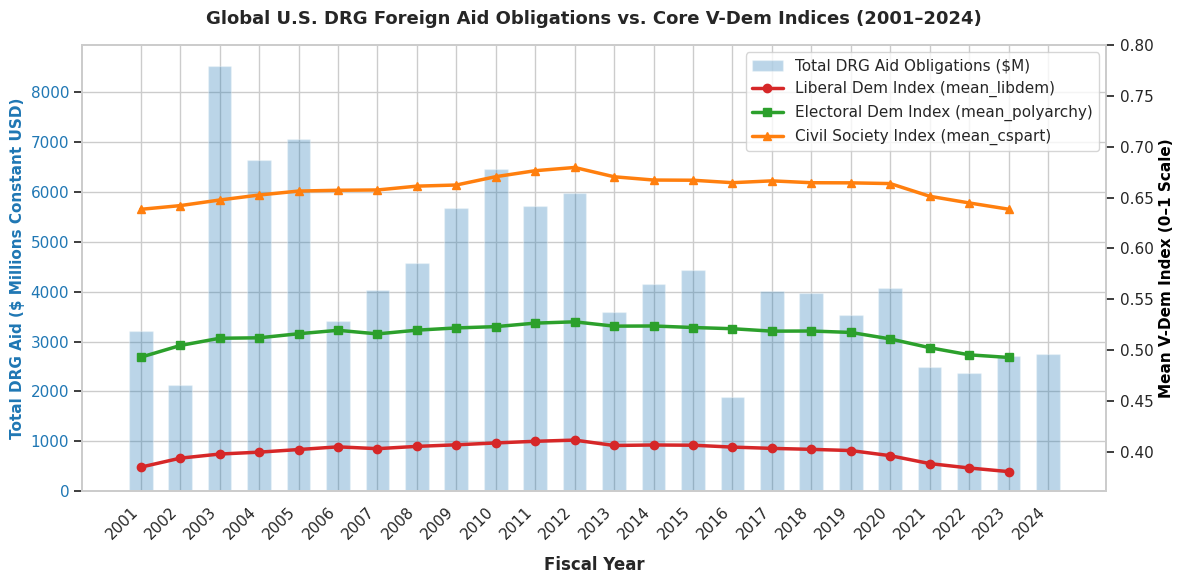

✅ Single-plot macro trends chart saved to: ../outputs/fig1_global_macro_trends_single.png


In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary Axis: Total DRG Aid Obligations (Bars)
color_aid = '#1f77b4'  # Slate Blue
ax1.bar(
    global_summary['year'],
    global_summary['total_drg_aid_millions'],
    color=color_aid,
    alpha=0.3,
    width=0.6,
    label='Total DRG Aid Obligations ($M)'
)
ax1.set_xlabel('Fiscal Year', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_ylabel('Total DRG Aid ($ Millions Constant USD)', color=color_aid, fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_aid)
ax1.set_xticks(global_summary['year'])
ax1.set_xticklabels(global_summary['year'], rotation=45, ha='right')

# Secondary Axis: All 3 V-Dem Indices (Lines)
ax2 = ax1.twinx()
ax2.plot(
    global_summary['year'],
    global_summary['mean_libdem'],
    color='#d62728', linewidth=2.5, marker='o',
    label='Liberal Dem Index (mean_libdem)'
)
ax2.plot(
    global_summary['year'],
    global_summary['mean_polyarchy'],
    color='#2ca02c', linewidth=2.5, marker='s',
    label='Electoral Dem Index (mean_polyarchy)'
)
ax2.plot(
    global_summary['year'],
    global_summary['mean_cspart'],
    color='#ff7f0e', linewidth=2.5, marker='^',
    label='Civil Society Index (mean_cspart)'
)

ax2.set_ylabel('Mean V-Dem Index (0–1 Scale)', color='black', fontsize=11, fontweight='bold')

# ==========================================
# DYNAMIC Y-LIMITS FOR ALL 3 LINES
# ==========================================
# 1. Calculate overall min and max across all 3 indices
all_indices_min = global_summary[['mean_libdem', 'mean_polyarchy', 'mean_cspart']].min().min()
all_indices_max = global_summary[['mean_libdem', 'mean_polyarchy', 'mean_cspart']].max().max()

# 2. Add 5% padding to min and max (bounded to maximum 1.0)
y_min = max(0, all_indices_min * 0.95)
y_max = min(1.0, .8)

# 3. Apply dynamic range
ax2.set_ylim(y_min, y_max)
ax2.grid(False)

ax2.grid(False)

# Combine handles and labels from both axes into one cohesive legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', frameon=True)

plt.title('Global U.S. DRG Foreign Aid Obligations vs. Core V-Dem Indices (2001–2024)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()

# 1. Save FIRST before plt.show() clears the canvas
output_single_plot_path = "../outputs/fig1_global_macro_trends_single.png"
plt.savefig(output_single_plot_path, dpi=300, bbox_inches='tight')

# 2. Display SECOND
plt.show()

print(f"✅ Single-plot macro trends chart saved to: {output_single_plot_path}")

In [ ]:
# ==========================================
# 1. FEATURE ENGINEERING FOR visual regressions of lagged democracy shifts to relative percentage changes in constant DRG aid obligations

# ==========================================
# Sort panel data by country and year to ensure accurate group calculations
df = df.sort_values(by=['country_text_id', 'year']).copy()

# Calculate year-over-year percentage change in constant DRG Aid Obligations (%)
# % Delta Aid_t = (Aid_t - Aid_t-1) / Aid_t-1 * 100
df['aid_pct_change'] = df.groupby('country_text_id')['aid_constant_amount'].pct_change() * 100

# Calculate 1-Year Lagged Democracy Delta
# Delta Dem_t-1 = Dem_t-1 - Dem_t-2
# First create t-1 and t-2 lagged scores per country
df['libdem_lag1'] = df.groupby('country_text_id')['v2x_libdem'].shift(1)
df['libdem_lag2'] = df.groupby('country_text_id')['v2x_libdem'].shift(2)

# Compute lagged shift: (Dem_t-1 - Dem_t-2)
df['libdem_shift_lag1'] = df['libdem_lag1'] - df['libdem_lag2']

In [ ]:
# ==========================================
# 2. FILTER OUTLIERS & PREPARE CLEAN REGRESSION SUBSET
# ==========================================
# Filter out non-aid or extreme percentage spikes (e.g., within -100% to +200% change)
# and drop missing values from lag/delta calculations
reg_df = df[
    (df['aid_pct_change'].notna()) & # GIRL COME BACK TO THIS
    (df['libdem_shift_lag1'].notna()) &
    (df['aid_pct_change'].between(-100, 200)) &
    (~np.isinf(df['aid_pct_change']))
].copy()

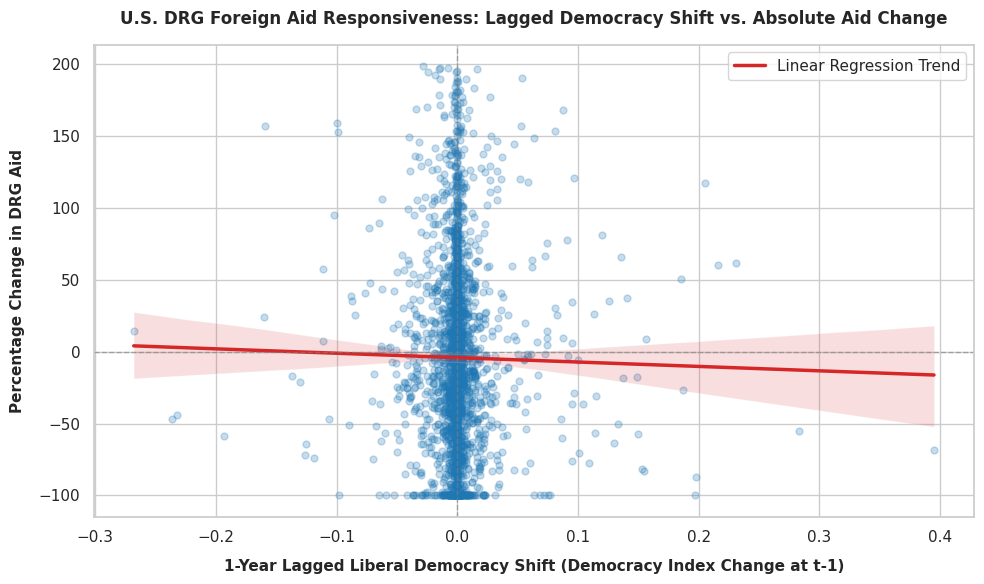

Visual regression chart successfully saved to: ../outputs/fig2_visual_regression_responsiveness.png


In [ ]:
# Build visual regression
fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(
    data=reg_df,
    x='libdem_shift_lag1',
    y='aid_pct_change',
    ax=ax,
    scatter_kws={'alpha': 0.25, 'color': '#1f77b4', 's': 25},
    line_kws={'color': '#d62728', 'linewidth': 2.5, 'label': 'Linear Regression Trend'}
)

# Reference lines at zero
ax.axhline(0, color='gray', linestyle='--', alpha=0.6, linewidth=1)
ax.axvline(0, color='gray', linestyle='--', alpha=0.6, linewidth=1)

# Clean plain-text titles and axis labels (no backslashes or special LaTeX codes)
ax.set_title('U.S. DRG Foreign Aid Responsiveness: Lagged Democracy Shift vs. Absolute Aid Change', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('1-Year Lagged Liberal Democracy Shift (Democracy Index Change at t-1)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Percentage Change in DRG Aid', fontsize=11, fontweight='bold', labelpad=10)
ax.legend(loc='upper right')

plt.tight_layout()

# Save FIRST, then show
output_reg_path = "../outputs/fig2_visual_regression_responsiveness.png"
plt.savefig(output_reg_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Visual regression chart successfully saved to: {output_reg_path}")

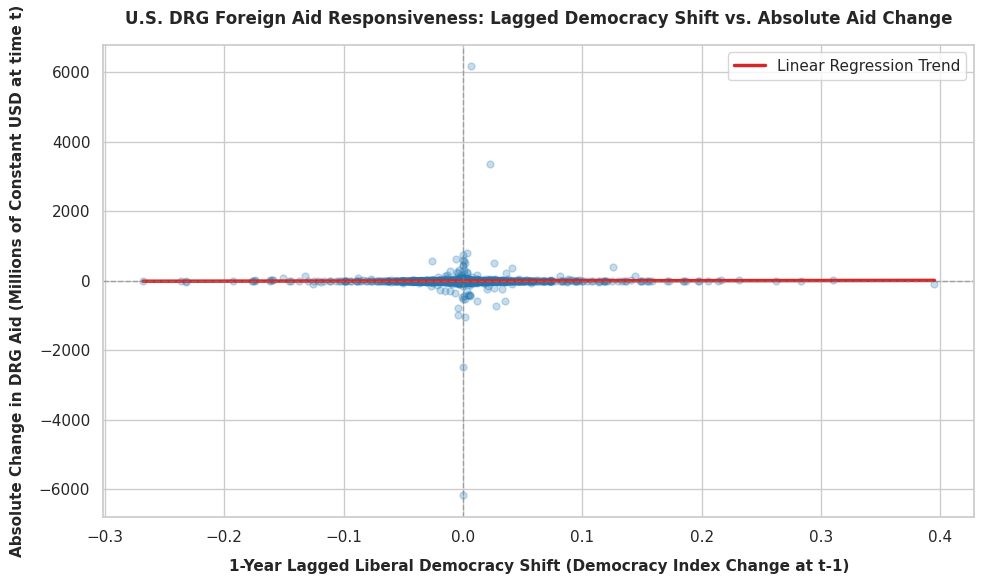

Visual regression chart successfully saved to: ../outputs/fig2_visual_regression_responsiveness.png


In [ ]:
# Sort panel data by country and year
df = df.sort_values(by=['country_text_id', 'year']).copy()

# Convert raw aid to Millions Constant USD
df['aid_millions'] = df['aid_constant_amount'] / 1e6

# Calculate year-over-year absolute dollar change: Delta Aid_t = Aid_t - Aid_t-1 ($ Millions)
df['aid_delta_millions'] = df.groupby('country_text_id')['aid_millions'].diff()

# Calculate 1-Year Lagged Democracy Shift: Delta Dem_t-1 = Dem_t-1 - Dem_t-2
df['libdem_lag1'] = df.groupby('country_text_id')['v2x_libdem'].shift(1)
df['libdem_lag2'] = df.groupby('country_text_id')['v2x_libdem'].shift(2)
df['libdem_shift_lag1'] = df['libdem_lag1'] - df['libdem_lag2']

# Subset valid non-null lag rows
reg_df = df[df['aid_delta_millions'].notna() & df['libdem_shift_lag1'].notna()].copy()

# Build visual regression
fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(
    data=reg_df,
    x='libdem_shift_lag1',
    y='aid_delta_millions',
    ax=ax,
    scatter_kws={'alpha': 0.25, 'color': '#1f77b4', 's': 25},
    line_kws={'color': '#d62728', 'linewidth': 2.5, 'label': 'Linear Regression Trend'}
)

# Reference lines at zero
ax.axhline(0, color='gray', linestyle='--', alpha=0.6, linewidth=1)
ax.axvline(0, color='gray', linestyle='--', alpha=0.6, linewidth=1)

# Clean plain-text labels (no backslashes or special formatting)
ax.set_title('U.S. DRG Foreign Aid Responsiveness: Lagged Democracy Shift vs. Absolute Aid Change', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('1-Year Lagged Liberal Democracy Shift (Democracy Index Change at t-1)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Absolute Change in DRG Aid (Millions of Constant USD at time t)', fontsize=11, fontweight='bold', labelpad=10)
ax.legend(loc='upper right')

plt.tight_layout()

# Save FIRST, then show
output_reg_path = "../outputs/fig2_visual_regression_responsiveness.png"
plt.savefig(output_reg_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Visual regression chart successfully saved to: {output_reg_path}")

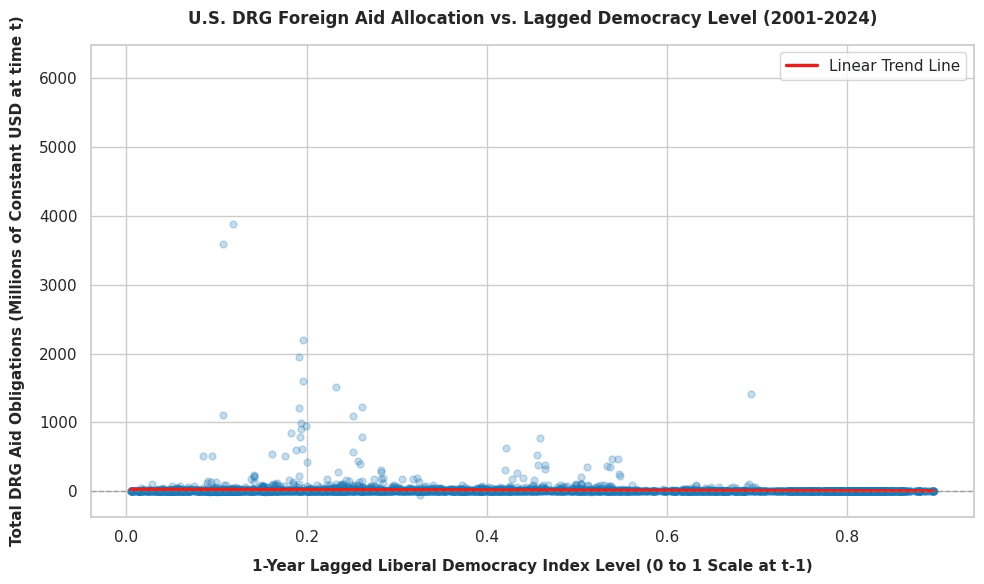

Static level regression chart saved to: ../outputs/fig2_static_level_regression.png


In [ ]:
# static democracy vs static aid

# Sort panel data by country and year
df = df.sort_values(by=['country_text_id', 'year']).copy()

# Convert raw aid to Millions Constant USD
df['aid_millions'] = df['aid_constant_amount'] / 1e6

# Subset valid non-null rows
level_df = df[df['aid_millions'].notna() & df['v2x_libdem_lag1'].notna()].copy()

# Build visual regression for static levels
fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(
    data=level_df,
    x='v2x_libdem_lag1',
    y='aid_millions',
    ax=ax,
    scatter_kws={'alpha': 0.25, 'color': '#1f77b4', 's': 25},
    line_kws={'color': '#d62728', 'linewidth': 2.5, 'label': 'Linear Trend Line'}
)

# Reference line at zero aid
ax.axhline(0, color='gray', linestyle='--', alpha=0.6, linewidth=1)

# Clean plain-text labels (no backslashes or formatting issues)
ax.set_title('U.S. DRG Foreign Aid Allocation vs. Lagged Democracy Level (2001-2024)', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('1-Year Lagged Liberal Democracy Index Level (0 to 1 Scale at t-1)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Total DRG Aid Obligations (Millions of Constant USD at time t)', fontsize=11, fontweight='bold', labelpad=10)
ax.legend(loc='upper right')

plt.tight_layout()

# Save FIRST, then display
output_level_path = "../outputs/fig2_static_level_regression.png"
plt.savefig(output_level_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Static level regression chart saved to: {output_level_path}")

In [21]:
# Calculate 1-year lagged democracy shifts and aid shifts
df['libdem_shift_lag1'] = df['v2x_libdem_lag1'] - df['v2x_libdem_lag2']
df['aid_delta_millions'] = df.groupby('country_text_id')['aid_millions'].diff()

# Filter out countries with very low overall aid (e.g., total aid < $10M across panel)
country_totals = df.groupby(['country_text_id', 'country_name'])['aid_millions'].sum().reset_index()
valid_countries = country_totals[country_totals['aid_millions'] >= 10]['country_text_id']

# Compute metrics per country
case_selection_list = []

for c_id in valid_countries:
    c_df = df[df['country_text_id'] == c_id].dropna(subset=['v2x_libdem_lag1', 'aid_delta_millions'])

    if len(c_df) >= 8:  # Ensure sufficient time-series history
        # Correlation between lagged dem shift and aid shift
        corr = c_df['libdem_shift_lag1'].corr(c_df['aid_delta_millions'])

        # Overall trajectory metrics
        initial_dem = c_df['v2x_libdem'].iloc[0]
        final_dem = c_df['v2x_libdem'].iloc[-1]
        dem_net_change = final_dem - initial_dem

        total_aid = c_df['aid_millions'].sum()
        mean_aid = c_df['aid_millions'].mean()
        c_name = c_df['country_name'].iloc[0]

        case_selection_list.append({
            'country_text_id': c_id,
            'country_name': c_name,
            'correlation': corr,
            'dem_net_change': dem_net_change,
            'total_aid_millions': total_aid,
            'mean_aid_millions': mean_aid,
            'n_obs': len(c_df)
        })

cases_df = pd.DataFrame(case_selection_list)

# ---------------------------------------------------------
# DISPLAY TOP CANDIDATES PER ARCHETYPE
# ---------------------------------------------------------
print("=== 1. HIGH RESPONSIVENESS (Strong Positive Correlation) ===")
display(cases_df.sort_values(by='correlation', ascending=False)[['country_name', 'correlation', 'dem_net_change', 'mean_aid_millions']].head(5).round(3))

print("\n=== 2. PROMINENT BACKSLIDERS (Largest Net Negative Democracy Shift) ===")
display(cases_df.sort_values(by='dem_net_change', ascending=True)[['country_name', 'dem_net_change', 'correlation', 'mean_aid_millions']].head(5).round(3))

print("\n=== 3. PROMINENT IMPROVERS (Largest Net Positive Democracy Shift) ===")
display(cases_df.sort_values(by='dem_net_change', ascending=False)[['country_name', 'dem_net_change', 'correlation', 'mean_aid_millions']].head(5).round(3))

print("\n=== 4. GEOPOLITICAL HEAVYWEIGHTS (High Total Aid, Low/Negative Correlation) ===")
heavyweights = cases_df[cases_df['mean_aid_millions'] > cases_df['mean_aid_millions'].quantile(0.75)]
display(heavyweights.sort_values(by='correlation', ascending=True)[['country_name', 'correlation', 'dem_net_change', 'mean_aid_millions']].head(5).round(3))

=== 1. HIGH RESPONSIVENESS (Strong Positive Correlation) ===


/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,country_name,correlation,dem_net_change,mean_aid_millions
93,South Sudan,0.582,-0.030,38.666
63,Burma/Myanmar,0.570,-0.003,24.824
29,Ethiopia,0.551,-0.004,10.234
97,Tajikistan,0.462,-0.044,11.589
95,Chad,0.459,-0.044,1.081



=== 2. PROMINENT BACKSLIDERS (Largest Net Negative Democracy Shift) ===


,country_name,dem_net_change,correlation,mean_aid_millions
40,Hungary,-0.432,0.124,0.917
101,Türkiye,-0.379,0.012,2.150
73,Nicaragua,-0.356,0.368,18.187
79,Poland,-0.356,0.027,280.807
42,India,-0.314,-0.187,2.059



=== 3. PROMINENT IMPROVERS (Largest Net Positive Democracy Shift) ===


,country_name,dem_net_change,correlation,mean_aid_millions
33,The Gambia,0.395,-0.226,0.995
74,Nepal,0.307,0.206,14.067
54,Liberia,0.263,0.064,32.069
30,Georgia,0.248,-0.204,31.819
58,Moldova,0.221,-0.165,19.692



=== 4. GEOPOLITICAL HEAVYWEIGHTS (High Total Aid, Low/Negative Correlation) ===


,country_name,correlation,dem_net_change,mean_aid_millions
47,Jordan,-0.640,0.119,54.514
77,Peru,-0.464,-0.076,35.506
82,Palestine/West Bank,-0.444,-0.152,85.864
39,Haiti,-0.309,-0.181,52.207
19,Democratic Republic of the Congo,-0.281,0.067,29.412


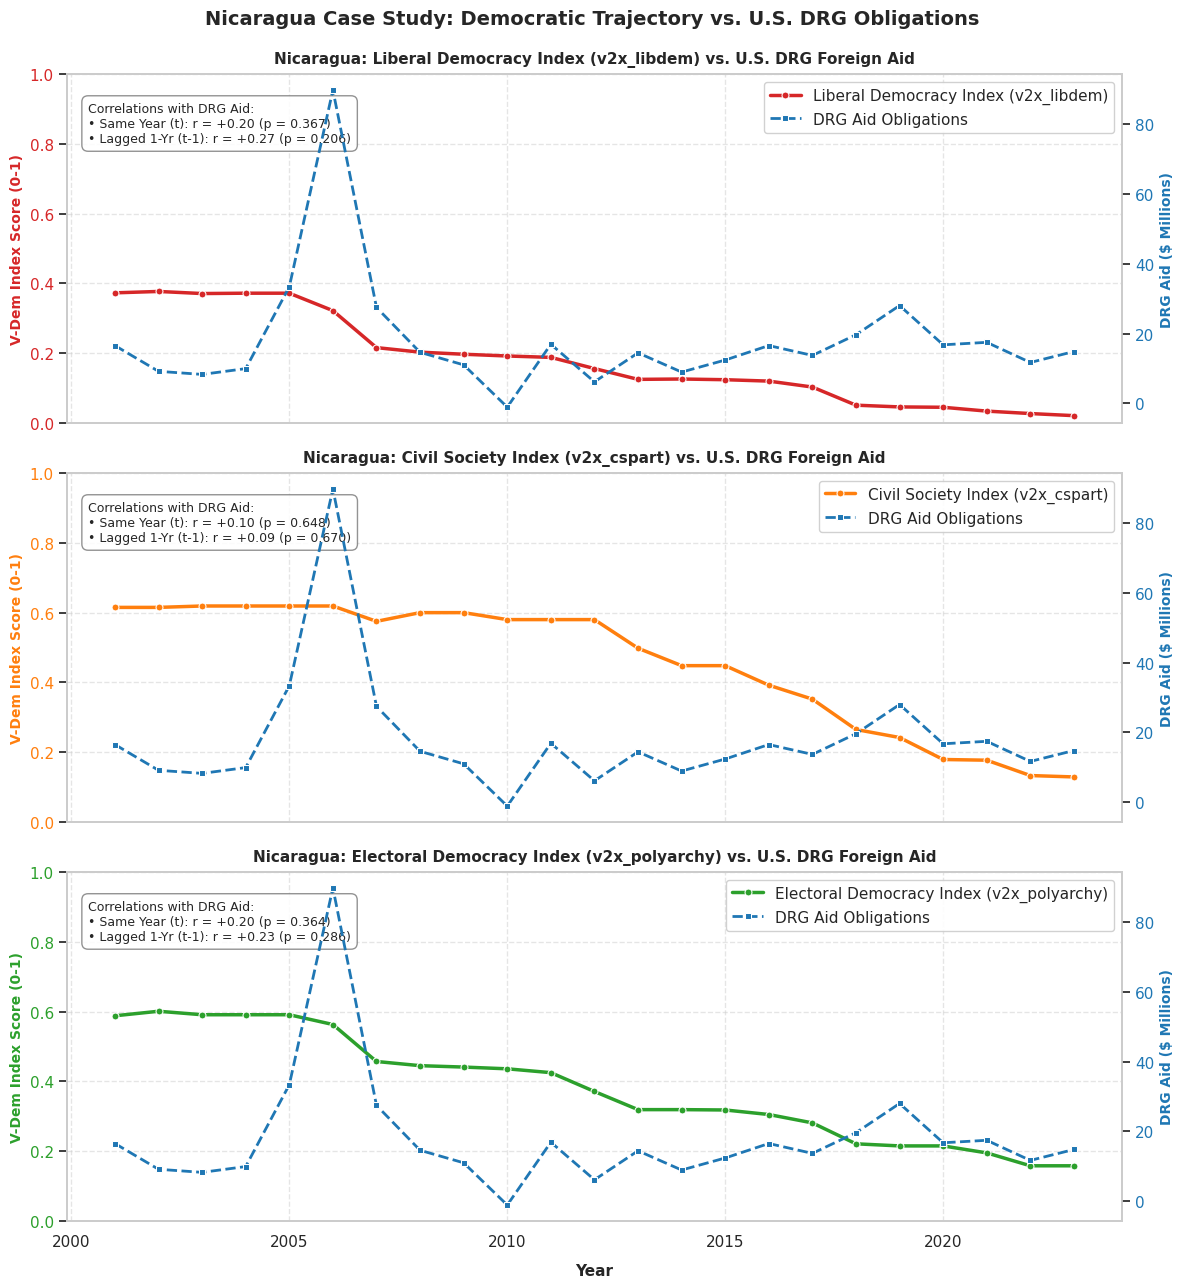

Annotated Nicaragua case study chart saved to: ../outputs/fig_nicaragua_case_study_annotated.png


In [26]:
# Filter data for Nicaragua and sort by year
nicaragua_df = df[df['country_name'] == 'Nicaragua'].sort_values(by='year').copy()

# Define indices and clean display titles
indices = [
    ('v2x_libdem', 'Liberal Democracy Index (v2x_libdem)', '#d62728'),      # Red
    ('v2x_cspart', 'Civil Society Index (v2x_cspart)', '#ff7f0e'),          # Orange
    ('v2x_polyarchy', 'Electoral Democracy Index (v2x_polyarchy)', '#2ca02c') # Green
]

# Create 3x1 stacked subplot grid
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 13), sharex=True)

for i, (col, title, color) in enumerate(indices):
    ax1 = axes[i]

    # ---------------------------------------------------------
    # Calculate Pearson Correlation (Contemporaneous & Lagged)
    # ---------------------------------------------------------
    # Contemporaneous (t vs t)
    valid_curr = nicaragua_df[[col, 'aid_millions']].dropna()
    r_curr, p_curr = pearsonr(valid_curr[col], valid_curr['aid_millions'])

    # Lagged (t-1 vs t)
    valid_lag = nicaragua_df[[f'{col}_lag1', 'aid_millions']].dropna()
    r_lag, p_lag = pearsonr(valid_lag[f'{col}_lag1'], valid_lag['aid_millions'])

    # Format correlation text box content
    corr_text = (
        f"Correlations with DRG Aid:\n"
        f"• Same Year (t): r = {r_curr:+.2f} (p = {p_curr:.3f})\n"
        f"• Lagged 1-Yr (t-1): r = {r_lag:+.2f} (p = {p_lag:.3f})"
    )

    # ---------------------------------------------------------
    # Primary Y-Axis (Left): V-Dem Index Score (0 to 1)
    # ---------------------------------------------------------
    sns.lineplot(
        data=nicaragua_df,
        x='year',
        y=col,
        ax=ax1,
        color=color,
        linewidth=2.5,
        marker='o',
        markersize=5,
        label=title
    )
    ax1.set_ylabel('V-Dem Index Score (0-1)', fontsize=10, fontweight='bold', color=color)
    ax1.set_ylim(0, 1)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # ---------------------------------------------------------
    # Secondary Y-Axis (Right): DRG Aid Obligations ($ Millions)
    # ---------------------------------------------------------
    ax2 = ax1.twinx()
    sns.lineplot(
        data=nicaragua_df,
        x='year',
        y='aid_millions',
        ax=ax2,
        color='#1f77b4',       # Blue for DRG Aid
        linewidth=2.0,
        linestyle='--',
        marker='s',
        markersize=4,
        label='DRG Aid Obligations'
    )
    ax2.set_ylabel('DRG Aid ($ Millions)', fontsize=10, fontweight='bold', color='#1f77b4')
    ax2.tick_params(axis='y', labelcolor='#1f77b4')
    ax2.grid(False)

    # Panel Title & Legends
    ax1.set_title(f'Nicaragua: {title} vs. U.S. DRG Foreign Aid', fontsize=11, fontweight='bold', pad=8)

    # Combine dual legends cleanly inside each panel (upper right)
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
    if ax2.get_legend():
        ax2.get_legend().remove()

    # Annotate Correlation Box in the upper left of each subplot
    ax1.text(
        0.02, 0.92, corr_text,
        transform=ax1.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.85)
    )

# Common X-axis settings
axes[2].set_xlabel('Year', fontsize=11, fontweight='bold', labelpad=10)

plt.suptitle('Nicaragua Case Study: Democratic Trajectory vs. U.S. DRG Obligations', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()

# Save FIRST, then display
output_case_path = "../outputs/fig_nicaragua_case_study_annotated.png"
plt.savefig(output_case_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Annotated Nicaragua case study chart saved to: {output_case_path}")

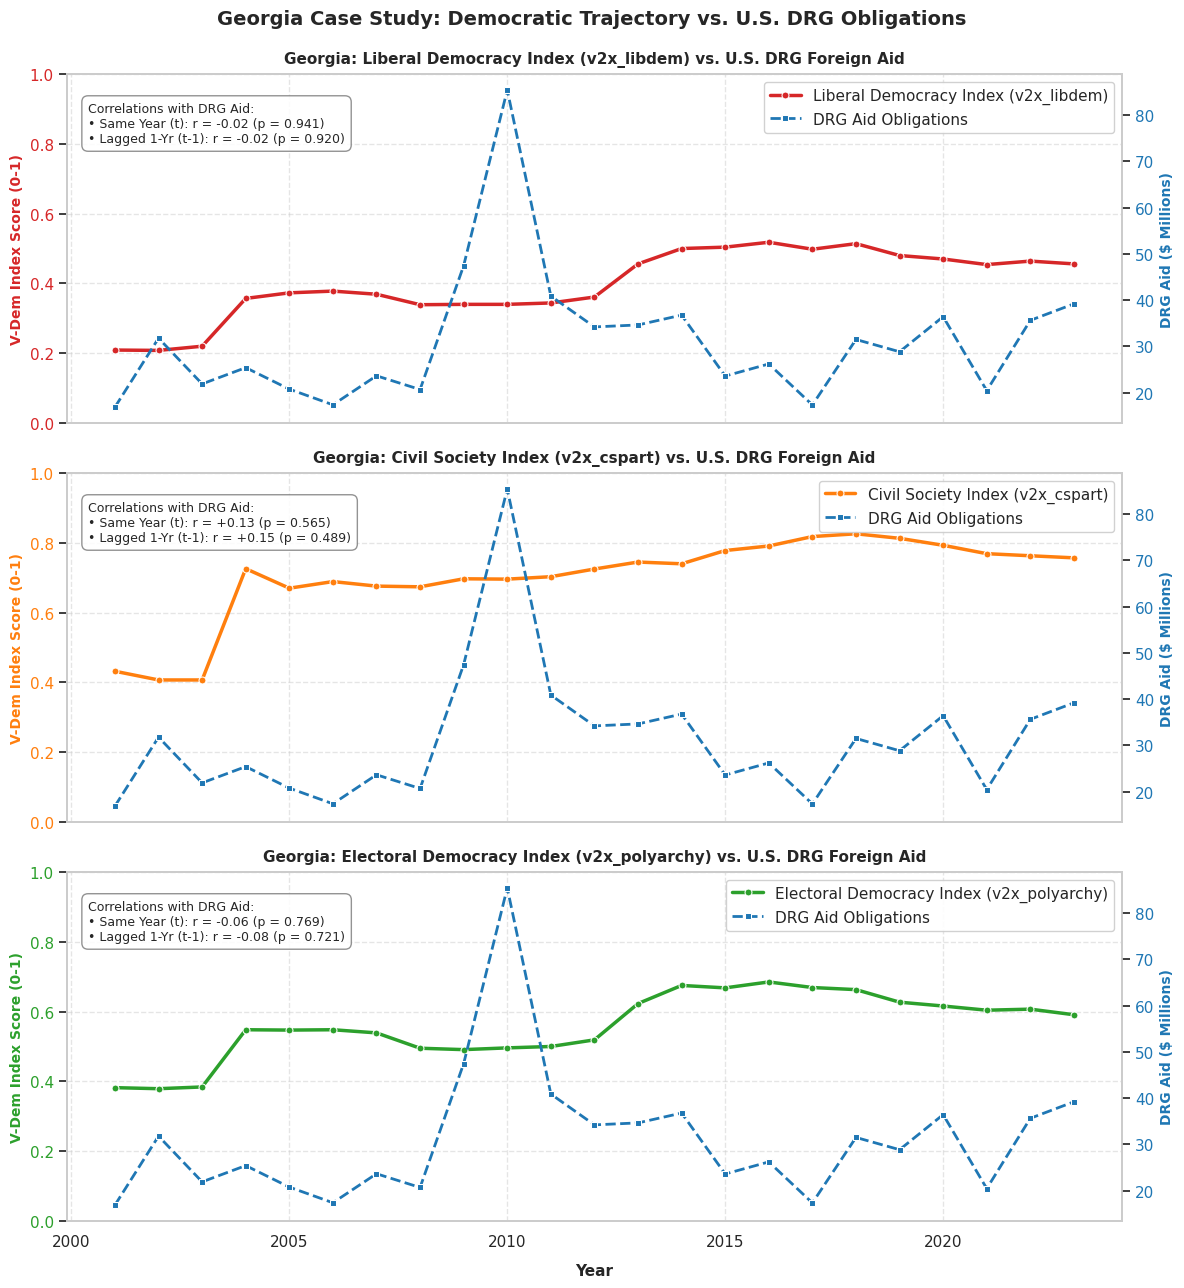

Annotated Georgia case study chart saved to: ../outputs/fig_georgia_case_study_annotated.png


In [27]:
# ==========================================
# GEORGIA
# ==========================================

# Filter data for Georgia and sort by year
georgia_df = df[df['country_name'] == 'Georgia'].sort_values(by='year').copy()

# Define indices and clean display titles
indices = [
    ('v2x_libdem', 'Liberal Democracy Index (v2x_libdem)', '#d62728'),      # Red
    ('v2x_cspart', 'Civil Society Index (v2x_cspart)', '#ff7f0e'),          # Orange
    ('v2x_polyarchy', 'Electoral Democracy Index (v2x_polyarchy)', '#2ca02c') # Green
]

# Create 3x1 stacked subplot grid
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 13), sharex=True)

for i, (col, title, color) in enumerate(indices):
    ax1 = axes[i]

    # ---------------------------------------------------------
    # Calculate Pearson Correlation (Contemporaneous & Lagged)
    # ---------------------------------------------------------
    # Contemporaneous (t vs t)
    valid_curr = georgia_df[[col, 'aid_millions']].dropna()
    r_curr, p_curr = pearsonr(valid_curr[col], valid_curr['aid_millions'])

    # Lagged (t-1 vs t)
    valid_lag = georgia_df[[f'{col}_lag1', 'aid_millions']].dropna()
    r_lag, p_lag = pearsonr(valid_lag[f'{col}_lag1'], valid_lag['aid_millions'])

    # Format correlation text box content
    corr_text = (
        f"Correlations with DRG Aid:\n"
        f"• Same Year (t): r = {r_curr:+.2f} (p = {p_curr:.3f})\n"
        f"• Lagged 1-Yr (t-1): r = {r_lag:+.2f} (p = {p_lag:.3f})"
    )

    # ---------------------------------------------------------
    # Primary Y-Axis (Left): V-Dem Index Score (0 to 1)
    # ---------------------------------------------------------
    sns.lineplot(
        data=georgia_df,
        x='year',
        y=col,
        ax=ax1,
        color=color,
        linewidth=2.5,
        marker='o',
        markersize=5,
        label=title
    )
    ax1.set_ylabel('V-Dem Index Score (0-1)', fontsize=10, fontweight='bold', color=color)
    ax1.set_ylim(0, 1)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # ---------------------------------------------------------
    # Secondary Y-Axis (Right): DRG Aid Obligations ($ Millions)
    # ---------------------------------------------------------
    ax2 = ax1.twinx()
    sns.lineplot(
        data=georgia_df,
        x='year',
        y='aid_millions',
        ax=ax2,
        color='#1f77b4',       # Blue for DRG Aid
        linewidth=2.0,
        linestyle='--',
        marker='s',
        markersize=4,
        label='DRG Aid Obligations'
    )
    ax2.set_ylabel('DRG Aid ($ Millions)', fontsize=10, fontweight='bold', color='#1f77b4')
    ax2.tick_params(axis='y', labelcolor='#1f77b4')
    ax2.grid(False)

    # Panel Title & Legends
    ax1.set_title(f'Georgia: {title} vs. U.S. DRG Foreign Aid', fontsize=11, fontweight='bold', pad=8)

    # Combine dual legends cleanly inside each panel (upper right)
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
    if ax2.get_legend():
        ax2.get_legend().remove()

    # Annotate Correlation Box in the upper left of each subplot
    ax1.text(
        0.02, 0.92, corr_text,
        transform=ax1.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.85)
    )

# Common X-axis settings
axes[2].set_xlabel('Year', fontsize=11, fontweight='bold', labelpad=10)

plt.suptitle('Georgia Case Study: Democratic Trajectory vs. U.S. DRG Obligations', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()

# Save FIRST, then display
output_georgia_path = "../outputs/fig_georgia_case_study_annotated.png"
plt.savefig(output_georgia_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Annotated Georgia case study chart saved to: {output_georgia_path}")

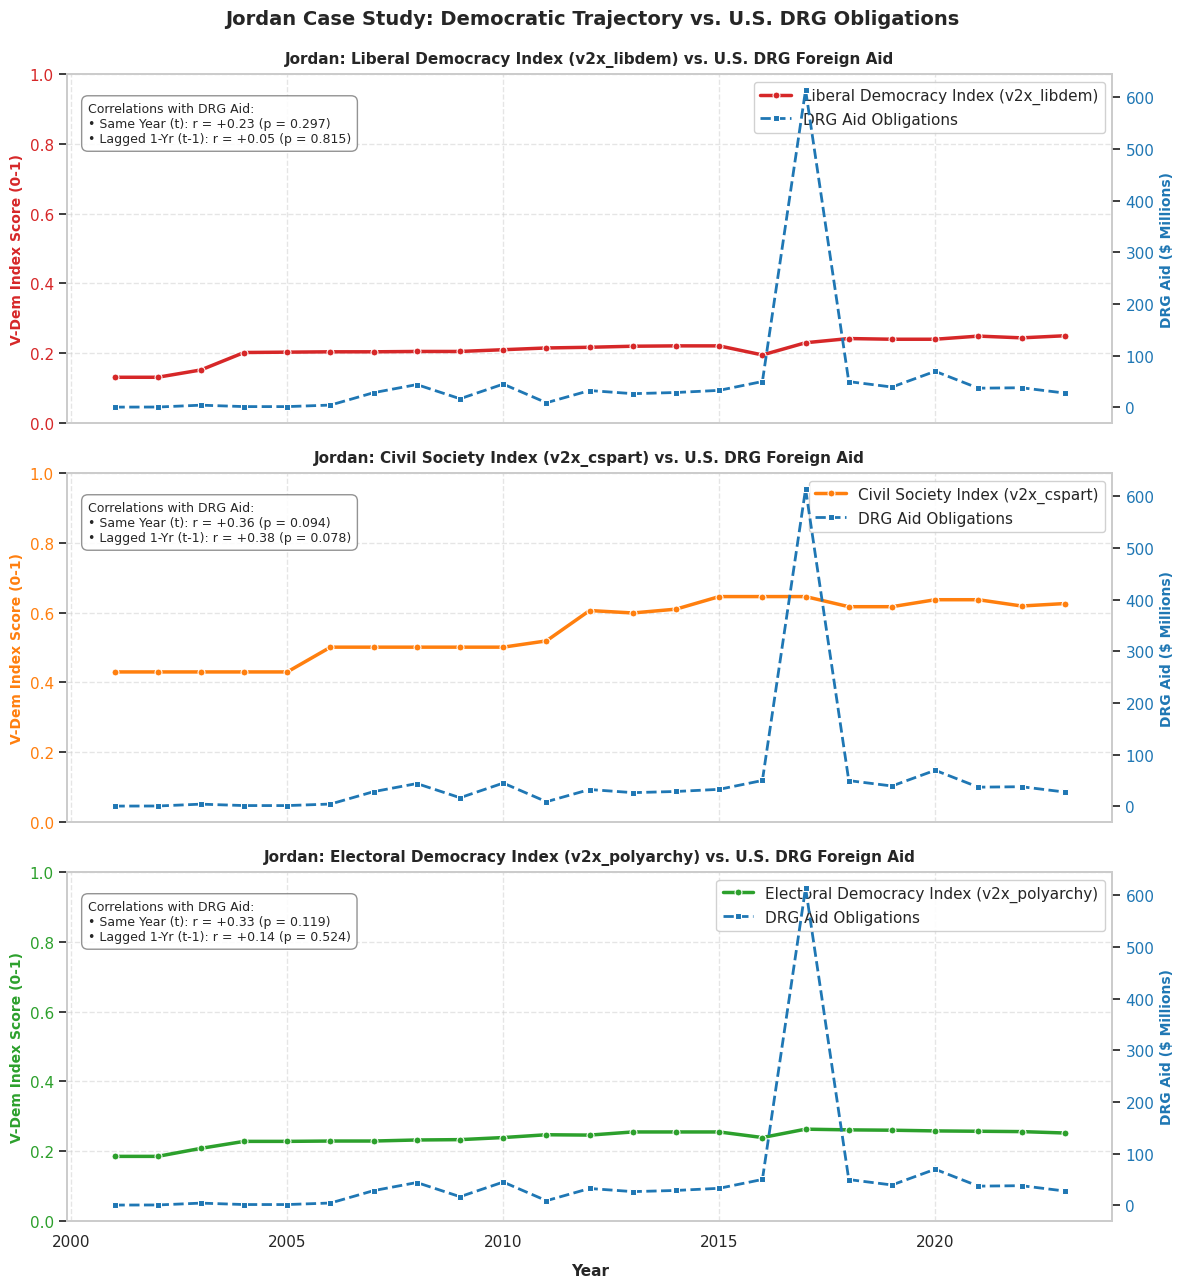

Annotated Jordan case study chart saved to: ../outputs/fig_jordan_case_study_annotated.png


In [29]:
# ==========================================
# JORDAN
# ==========================================

# Filter data for Jordan and sort by year
jordan_df = df[df['country_name'] == 'Jordan'].sort_values(by='year').copy()

# Define indices and clean display titles
indices = [
    ('v2x_libdem', 'Liberal Democracy Index (v2x_libdem)', '#d62728'),      # Red
    ('v2x_cspart', 'Civil Society Index (v2x_cspart)', '#ff7f0e'),          # Orange
    ('v2x_polyarchy', 'Electoral Democracy Index (v2x_polyarchy)', '#2ca02c') # Green
]

# Create 3x1 stacked subplot grid
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 13), sharex=True)

for i, (col, title, color) in enumerate(indices):
    ax1 = axes[i]

    # ---------------------------------------------------------
    # Calculate Pearson Correlation (Contemporaneous & Lagged)
    # ---------------------------------------------------------
    # Contemporaneous (t vs t)
    valid_curr = jordan_df[[col, 'aid_millions']].dropna()
    r_curr, p_curr = pearsonr(valid_curr[col], valid_curr['aid_millions'])

    # Lagged (t-1 vs t)
    valid_lag = jordan_df[[f'{col}_lag1', 'aid_millions']].dropna()
    r_lag, p_lag = pearsonr(valid_lag[f'{col}_lag1'], valid_lag['aid_millions'])

    # Format correlation text box content
    corr_text = (
        f"Correlations with DRG Aid:\n"
        f"• Same Year (t): r = {r_curr:+.2f} (p = {p_curr:.3f})\n"
        f"• Lagged 1-Yr (t-1): r = {r_lag:+.2f} (p = {p_lag:.3f})"
    )

    # ---------------------------------------------------------
    # Primary Y-Axis (Left): V-Dem Index Score (0 to 1)
    # ---------------------------------------------------------
    sns.lineplot(
        data=jordan_df,
        x='year',
        y=col,
        ax=ax1,
        color=color,
        linewidth=2.5,
        marker='o',
        markersize=5,
        label=title
    )
    ax1.set_ylabel('V-Dem Index Score (0-1)', fontsize=10, fontweight='bold', color=color)
    ax1.set_ylim(0, 1)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # ---------------------------------------------------------
    # Secondary Y-Axis (Right): DRG Aid Obligations ($ Millions)
    # ---------------------------------------------------------
    ax2 = ax1.twinx()
    sns.lineplot(
        data=jordan_df,
        x='year',
        y='aid_millions',
        ax=ax2,
        color='#1f77b4',       # Blue for DRG Aid
        linewidth=2.0,
        linestyle='--',
        marker='s',
        markersize=4,
        label='DRG Aid Obligations'
    )
    ax2.set_ylabel('DRG Aid ($ Millions)', fontsize=10, fontweight='bold', color='#1f77b4')
    ax2.tick_params(axis='y', labelcolor='#1f77b4')
    ax2.grid(False)

    # Panel Title & Legends
    ax1.set_title(f'Jordan: {title} vs. U.S. DRG Foreign Aid', fontsize=11, fontweight='bold', pad=8)

    # Combine dual legends cleanly inside each panel (upper right)
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
    if ax2.get_legend():
        ax2.get_legend().remove()

    # Annotate Correlation Box in the upper left of each subplot
    ax1.text(
        0.02, 0.92, corr_text,
        transform=ax1.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.85)
    )

# Common X-axis settings
axes[2].set_xlabel('Year', fontsize=11, fontweight='bold', labelpad=10)

plt.suptitle('Jordan Case Study: Democratic Trajectory vs. U.S. DRG Obligations', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()

# Save FIRST, then display
output_jordan_path = "../outputs/fig_jordan_case_study_annotated.png"
plt.savefig(output_jordan_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Annotated Jordan case study chart saved to: {output_jordan_path}")

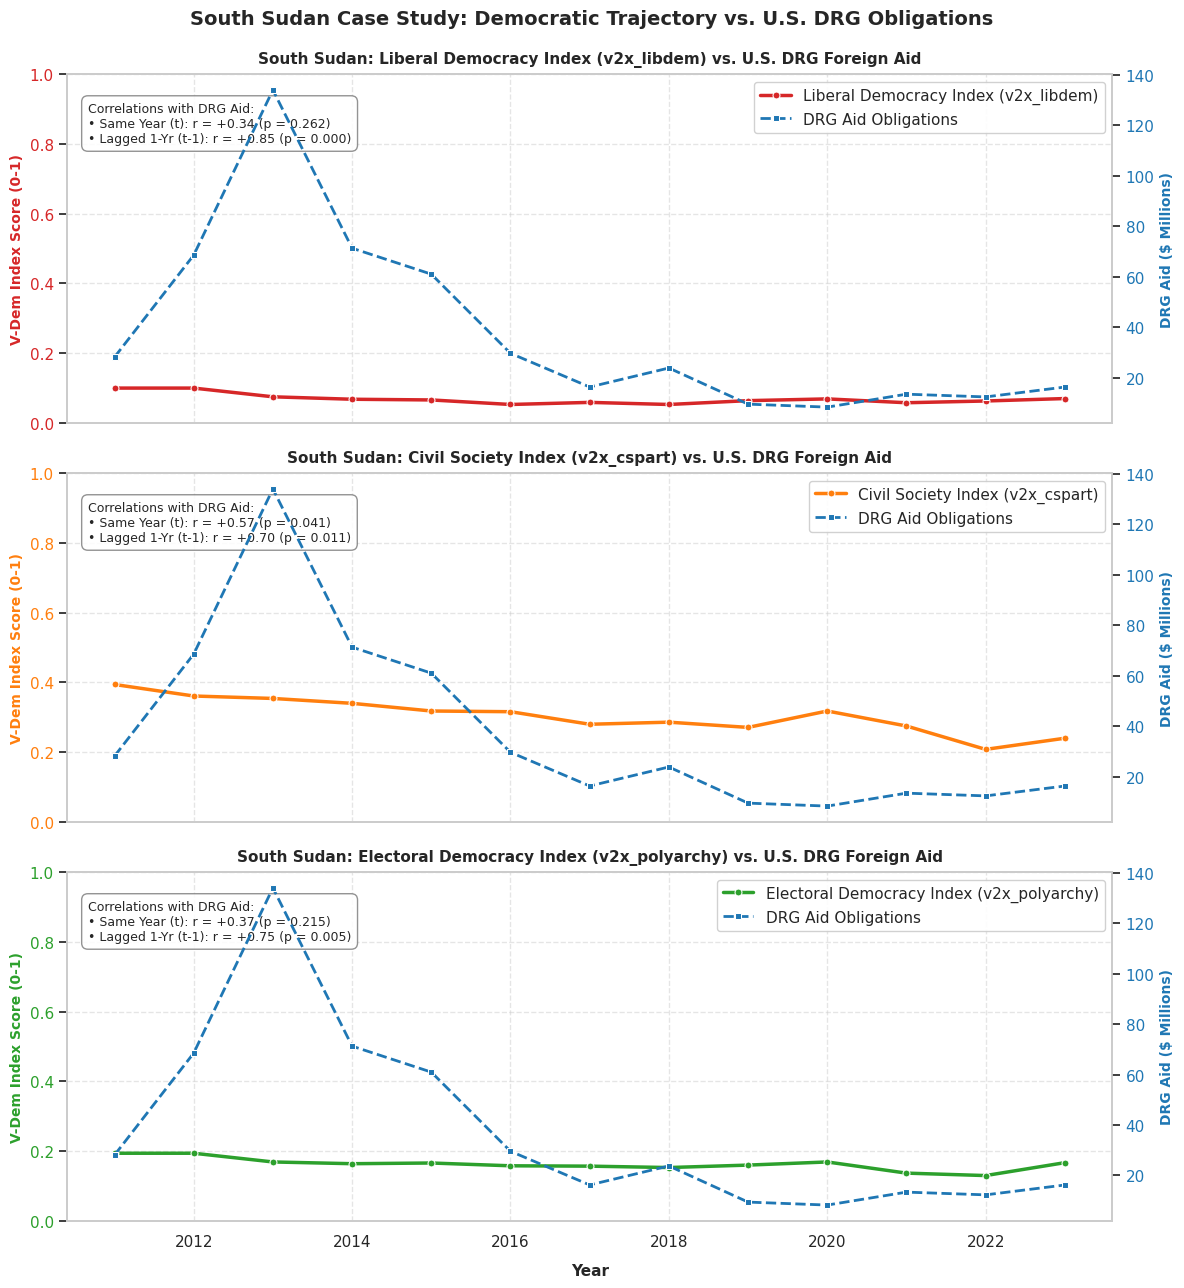

Annotated South Sudan case study chart saved to: ../outputs/fig_south_sudan_case_study_annotated.png


In [31]:
# ==========================================
# SOUTH SUDAN
# ==========================================

# Filter data for South Sudan and sort by year
south_sudan_df = df[df['country_name'] == 'South Sudan'].sort_values(by='year').copy()

# Define indices and clean display titles
indices = [
    ('v2x_libdem', 'Liberal Democracy Index (v2x_libdem)', '#d62728'),      # Red
    ('v2x_cspart', 'Civil Society Index (v2x_cspart)', '#ff7f0e'),          # Orange
    ('v2x_polyarchy', 'Electoral Democracy Index (v2x_polyarchy)', '#2ca02c') # Green
]

# Create 3x1 stacked subplot grid
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 13), sharex=True)

for i, (col, title, color) in enumerate(indices):
    ax1 = axes[i]

    # ---------------------------------------------------------
    # Calculate Pearson Correlation (Contemporaneous & Lagged)
    # ---------------------------------------------------------
    # Contemporaneous (t vs t)
    valid_curr = south_sudan_df[[col, 'aid_millions']].dropna()
    if len(valid_curr) > 1:
        r_curr, p_curr = pearsonr(valid_curr[col], valid_curr['aid_millions'])
        curr_text = f"• Same Year (t): r = {r_curr:+.2f} (p = {p_curr:.3f})"
    else:
        curr_text = "• Same Year (t): N/A"

    # Lagged (t-1 vs t)
    valid_lag = south_sudan_df[[f'{col}_lag1', 'aid_millions']].dropna()
    if len(valid_lag) > 1:
        r_lag, p_lag = pearsonr(valid_lag[f'{col}_lag1'], valid_lag['aid_millions'])
        lag_text = f"• Lagged 1-Yr (t-1): r = {r_lag:+.2f} (p = {p_lag:.3f})"
    else:
        lag_text = "• Lagged 1-Yr (t-1): N/A"

    # Format correlation text box content
    corr_text = f"Correlations with DRG Aid:\n{curr_text}\n{lag_text}"

    # ---------------------------------------------------------
    # Primary Y-Axis (Left): V-Dem Index Score (0 to 1)
    # ---------------------------------------------------------
    sns.lineplot(
        data=south_sudan_df,
        x='year',
        y=col,
        ax=ax1,
        color=color,
        linewidth=2.5,
        marker='o',
        markersize=5,
        label=title
    )
    ax1.set_ylabel('V-Dem Index Score (0-1)', fontsize=10, fontweight='bold', color=color)
    ax1.set_ylim(0, 1)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # ---------------------------------------------------------
    # Secondary Y-Axis (Right): DRG Aid Obligations ($ Millions)
    # ---------------------------------------------------------
    ax2 = ax1.twinx()
    sns.lineplot(
        data=south_sudan_df,
        x='year',
        y='aid_millions',
        ax=ax2,
        color='#1f77b4',       # Blue for DRG Aid
        linewidth=2.0,
        linestyle='--',
        marker='s',
        markersize=4,
        label='DRG Aid Obligations'
    )
    ax2.set_ylabel('DRG Aid ($ Millions)', fontsize=10, fontweight='bold', color='#1f77b4')
    ax2.tick_params(axis='y', labelcolor='#1f77b4')
    ax2.grid(False)

    # Panel Title & Legends
    ax1.set_title(f'South Sudan: {title} vs. U.S. DRG Foreign Aid', fontsize=11, fontweight='bold', pad=8)

    # Combine dual legends cleanly inside each panel (upper right)
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
    if ax2.get_legend():
        ax2.get_legend().remove()

    # Annotate Correlation Box in the upper left of each subplot
    ax1.text(
        0.02, 0.92, corr_text,
        transform=ax1.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.85)
    )

# Common X-axis settings
axes[2].set_xlabel('Year', fontsize=11, fontweight='bold', labelpad=10)

plt.suptitle('South Sudan Case Study: Democratic Trajectory vs. U.S. DRG Obligations', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()

# Save FIRST, then display
output_south_sudan_path = "../outputs/fig_south_sudan_case_study_annotated.png"
plt.savefig(output_south_sudan_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Annotated South Sudan case study chart saved to: {output_south_sudan_path}")

In [32]:
# ==========================================
# DESCRIPTIVE SUMMARY TABLES - CASE STUDIES
# ==========================================

# Case study countries
cases = ['Nicaragua', 'Georgia', 'Jordan', 'South Sudan']

# Target variables and display mappings
target_vars = {
    'aid_millions': 'DRG Aid ($M)',
    'v2x_libdem': 'Liberal Dem (v2x_libdem)',
    'v2x_cspart': 'Civil Society (v2x_cspart)',
    'v2x_polyarchy': 'Electoral Dem (v2x_polyarchy)'
}

combined_case_stats = []

print("==========================================================================")
print("             CASE STUDY DESCRIPTIVE STATISTICS (2001–2024)                ")
print("==========================================================================")

for country in cases:
    c_df = df[df['country_name'] == country][list(target_vars.keys())]

    if c_df.empty:
        print(f"\n⚠️ Warning: No data found for country '{country}'")
        continue

    # Calculate statistics
    stats = c_df.describe().T
    stats['median'] = c_df.median()
    stats['country'] = country
    stats['variable_raw'] = stats.index
    stats['Variable'] = stats.index.map(target_vars)

    # Format and reorder columns
    stats = stats.rename(columns={
        'count': 'N',
        'mean': 'Mean',
        'std': 'Std Dev',
        'min': 'Min',
        'median': 'Median',
        'max': 'Max'
    })

    cols_order = ['country', 'Variable', 'N', 'Mean', 'Median', 'Std Dev', 'Min', 'Max']
    stats_formatted = stats[cols_order].reset_index(drop=True)

    # Cast N to integer
    stats_formatted['N'] = stats_formatted['N'].astype(int)

    # Store in list
    combined_case_stats.append(stats_formatted)

    # Display individual country summary
    print(f"\n--- {country.upper()} ---")
    display(stats_formatted.drop(columns=['country']).round(3))

# Concatenate all case study stats into a single DataFrame
all_cases_df = pd.concat(combined_case_stats, ignore_index=True)

# Save combined summary to CSV
output_csv_path = "../outputs/table2_case_studies_descriptive_stats.csv"
all_cases_df.round(3).to_csv(output_csv_path, index=False)
print(f"\n✅ All case study statistics saved to CSV: {output_csv_path}")

# Export Markdown formatted table for direct copying into report
output_md_path = "../outputs/table2_case_studies_descriptive_stats.md"
with open(output_md_path, "w") as f:
    f.write("# Case Studies Descriptive Summary Statistics\n\n")
    for country in cases:
        f.write(f"### {country}\n\n")
        country_sub = all_cases_df[all_cases_df['country'] == country].drop(columns=['country'])
        f.write(country_sub.round(3).to_markdown(index=False))
        f.write("\n\n---\n\n")

print(f"✅ Markdown tables saved for report embedding to: {output_md_path}")

             CASE STUDY DESCRIPTIVE STATISTICS (2001–2024)                

--- NICARAGUA ---


,Variable,N,Mean,Median,Std Dev,Min,Max
0,DRG Aid ($M),23,18.115,14.602,17.310,-1.100,89.819
1,Liberal Dem (v2x_libdem),23,0.181,0.156,0.126,0.021,0.377
2,Civil Society (v2x_cspart),23,0.456,0.575,0.181,0.129,0.619
3,Electoral Dem (v2x_polyarchy),23,0.383,0.371,0.153,0.158,0.601



--- GEORGIA ---


,Variable,N,Mean,Median,Std Dev,Min,Max
0,DRG Aid ($M),23,31.169,28.838,14.544,16.870,85.441
1,Liberal Dem (v2x_libdem),23,0.398,0.378,0.097,0.208,0.518
2,Civil Society (v2x_cspart),23,0.700,0.726,0.122,0.407,0.826
3,Electoral Dem (v2x_polyarchy),23,0.559,0.548,0.094,0.379,0.685



--- JORDAN ---


,Variable,N,Mean,Median,Std Dev,Min,Max
0,DRG Aid ($M),23,52.158,28.613,124.075,0.319,614.471
1,Liberal Dem (v2x_libdem),23,0.210,0.215,0.033,0.131,0.250
2,Civil Society (v2x_cspart),23,0.551,0.599,0.084,0.430,0.646
3,Electoral Dem (v2x_polyarchy),23,0.239,0.246,0.022,0.185,0.263



--- SOUTH SUDAN ---


,Variable,N,Mean,Median,Std Dev,Min,Max
0,DRG Aid ($M),13,37.852,23.775,36.571,8.281,133.947
1,Liberal Dem (v2x_libdem),13,0.069,0.066,0.015,0.053,0.100
2,Civil Society (v2x_cspart),13,0.305,0.316,0.051,0.208,0.394
3,Electoral Dem (v2x_polyarchy),13,0.163,0.164,0.018,0.130,0.194



✅ All case study statistics saved to CSV: ../outputs/table2_case_studies_descriptive_stats.csv
✅ Markdown tables saved for report embedding to: ../outputs/table2_case_studies_descriptive_stats.md
